# Baselines (paper models) vs symbolic student — comparison

Reads parquet files off disk and overlays residuals, pulls, and an I68 resolution table.
Everything is driven by the `FILES` list in the config cell — add/remove/comment entries there.

**Per-file scaling.** Paper baselines use the paper normalization; symbolic runs use their own
tfrecord `labels_scale` (auto-read from `labels_scale.json` next to each parquet). One global
scale would distort the overlay, so each file carries its own.

**Auto kind detection.** SLIM files (no cotA, no sigmas) are automatically skipped on the α panel
and on the pull plots.

**Fairness note for the writeup.** Baseline parquets were evaluated on the paper test set; the
symbolic runs on the centeredIncidence split. Resolution (I68) comparison is fair; bin-by-bin
*bias* overlays cross datasets, and Jennet's origin-offset point applies — read residual *shape*,
not absolute offset, across the two families.

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore")
pi = np.pi

In [2]:
#==============================================================================
# CONFIGURATION -- edit FILES, then Run All
#==============================================================================
BASE = "/depot/cms/private/users/kuang14/Smart_Pixel/smart-pixels-ml_symbolic/baseline_models"
SYM  = "/depot/cms/private/users/kuang14/Smart_Pixel"

# paper-pipeline normalization (applies to every baseline parquet)
PAPER_SCALE = (122.89689703635774, 30.903849401109394,
               6.560914919886437,  1.917222249583349)
# fallback for symbolic parquets if no labels_scale.json sits next to them
MOE_SCALE = None    # e.g. (75.0, 18.75, 6.577, 1.930)

def auto_scale(path):
    js = os.path.join(os.path.dirname(path), "labels_scale.json")
    if os.path.exists(js):
        return tuple(json.load(open(js))["labels_scale"])
    assert MOE_SCALE is not None, f"no labels_scale.json near {path} and MOE_SCALE unset"
    return MOE_SCALE

# scale="paper" -> PAPER_SCALE ; scale="auto" -> read labels_scale.json next to the parquet
FILES = [
    # ---- paper baselines (20t = information parity with the symbolic student) ----
    dict(path=f"{BASE}/20t-conv2d_MAX-vars.parquet",  label="Conv2D MAX (20t)",  color="black",      scale="paper"),
    dict(path=f"{BASE}/20t-conv2d_FULL-vars.parquet", label="Conv2D Full (20t)", color="dimgray",    scale="paper"),
    dict(path=f"{BASE}/20t-conv1d_FULL-vars.parquet", label="Conv1D Full (20t)", color="tab:blue",   scale="paper"),
    dict(path=f"{BASE}/20t-mlp_FULL-vars.parquet",    label="MLP Full (20t)",    color="tab:orange", scale="paper"),
    # ---- symbolic students (calibrated) ----
    dict(path=f"{SYM}/symbolic_ablation_nexp1/symbolic_n1_vars.parquet", label="Symbolic 1 formula", color="tab:purple", scale="auto"),
    # dict(path=f"{SYM}/symbolic_ablation_nexp2/symbolic_n2_vars.parquet", label="Symbolic MoE 2-exp", color="magenta",    scale="auto"),
    dict(path=f"{SYM}/symbolic_ablation_nexp4/symbolic_n4_vars.parquet", label="Symbolic MoE 4-exp", color="tab:green",  scale="auto"),
    # ---- 2t baselines: hardware-parity claim (keep as a SEPARATE plot, not mixed with 20t) ----
    # dict(path=f"{BASE}/2t-mlp_FULL-vars.parquet",     label="MLP Full (2t)",     color="tab:red",  scale="paper"),
]

# per-model parameter counts for the params-vs-resolution scatter (fill symbolic from summary.json)
PARAM_COUNTS = {
    "Conv2D MAX (20t)":  1898,
    "Conv2D Full (20t)": 1767,
    "Conv1D Full (20t)": 2734,
    "MLP Full (20t)":    2264,
    # "Symbolic 1 formula": 370,
    # "Symbolic MoE 4-exp": 3260,
}

SHOW_BANDS = False        # sigma bands on residual panels (busy with many files)
figsize_residuals = (16, 11)
figsize_pulls     = (16, 11)
output_dir = None         # e.g. "./plots" to save PNGs/CSV, or None
save_dpi   = 300

In [3]:
#==============================================================================
# LOAD + auto-detect kind + resolve per-file scale
#==============================================================================
entries = []
for f in FILES:
    if not os.path.exists(f["path"]):
        print("MISSING (skipped):", f["path"]); continue
    df = pd.read_parquet(f["path"])
    cols = set(df.columns)
    has_alpha = "cotA" in cols and "cotAtrue" in cols
    has_sigma = "sigmax" in cols
    scale = PAPER_SCALE if f["scale"] == "paper" else auto_scale(f["path"])
    entries.append(dict(df=df, label=f["label"], color=f["color"],
                        scale=np.asarray(scale, float),
                        has_alpha=has_alpha, has_sigma=has_sigma))
    kind = ("FULL/MAX" if has_alpha else "SLIM") + ("+sigma" if has_sigma else "")
    print(f"[{f['label']:<22s}] {len(df):>7d} rows | {kind:12s} | "
          f"scale=({scale[0]:.2f}, {scale[1]:.2f}, {scale[2]:.4f}, {scale[3]:.4f})")

assert entries, "nothing loaded -- check paths in FILES"
print(f"\n{len(entries)} files loaded.")

[Conv2D MAX (20t)      ]  108222 rows | FULL/MAX+sigma | scale=(122.90, 30.90, 6.5609, 1.9172)
[Conv2D Full (20t)     ]  108222 rows | FULL/MAX+sigma | scale=(122.90, 30.90, 6.5609, 1.9172)
[Conv1D Full (20t)     ]  108222 rows | FULL/MAX+sigma | scale=(122.90, 30.90, 6.5609, 1.9172)
[MLP Full (20t)        ]  108222 rows | FULL/MAX+sigma | scale=(122.90, 30.90, 6.5609, 1.9172)
[Symbolic 1 formula    ]  108222 rows | FULL/MAX+sigma | scale=(123.41, 30.93, 6.5775, 1.9296)
[Symbolic MoE 4-exp    ]  108222 rows | FULL/MAX+sigma | scale=(123.41, 30.93, 6.5775, 1.9296)

6 files loaded.


In [4]:
#==============================================================================
# HELPERS
#==============================================================================
def inverse_cot(c):
    return np.arctan2(1.0, np.asarray(c, float))     # stable, range (0, pi)

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def i68(r):
    """paper resolution metric: half-width of the minimal interval containing 68% of residuals"""
    r = np.sort(np.asarray(r)[np.isfinite(r)])
    n = len(r); k = int(np.ceil(0.68 * n))
    if k >= n: return (r[-1] - r[0]) / 2.0
    return (r[k:] - r[:n - k]).min() / 2.0

def get_phys(e, var):
    """(true, pred, sigma_or_None) in physical units; angles in DEGREES."""
    sx, sy, sa, sb = e["scale"]
    s = {"x": sx, "y": sy, "cotA": sa, "cotB": sb}[var]
    df = e["df"]
    if var in ("x", "y"):
        t, p = df[var + "true"].values * s, df[var].values * s
        sig = df["sigma" + var].values * s if e["has_sigma"] else None
        return t, p, sig
    t = np.degrees(inverse_cot(df[var + "true"].values * s))
    p = np.degrees(inverse_cot(df[var].values * s))
    sig = None
    if e["has_sigma"]:
        pu  = np.degrees(inverse_cot((df[var].values + df["sigma" + var].values) * s))
        pd_ = np.degrees(inverse_cot((df[var].values - df["sigma" + var].values) * s))
        sig = 0.5 * (np.abs(pu - p) + np.abs(pd_ - p))
    return t, p, sig

def residual_scatter(ax, t, p, color, label, nbins=50, sigma=None, band=False, alpha=0.18):
    res = t - p
    xmin, xmax = np.min(t), np.max(t)
    sns.regplot(x=t, y=res, x_bins=np.linspace(xmin, xmax, nbins),
                fit_reg=None, marker=".", ax=ax, color=color, label=label)
    if band and sigma is not None:
        step = (xmax - xmin) / nbins; ctrs = np.linspace(xmin, xmax, nbins)
        up, dn = [], []
        for i in range(nbins):
            m = (t > xmin + i*step) & (t < xmin + (i+1)*step)
            mu = res[m].mean() if m.sum() else np.nan
            sg = sigma[m].mean() if m.sum() else np.nan
            up.append(mu + sg); dn.append(mu - sg)
        ax.fill_between(ctrs, dn, up, alpha=alpha, color=color)

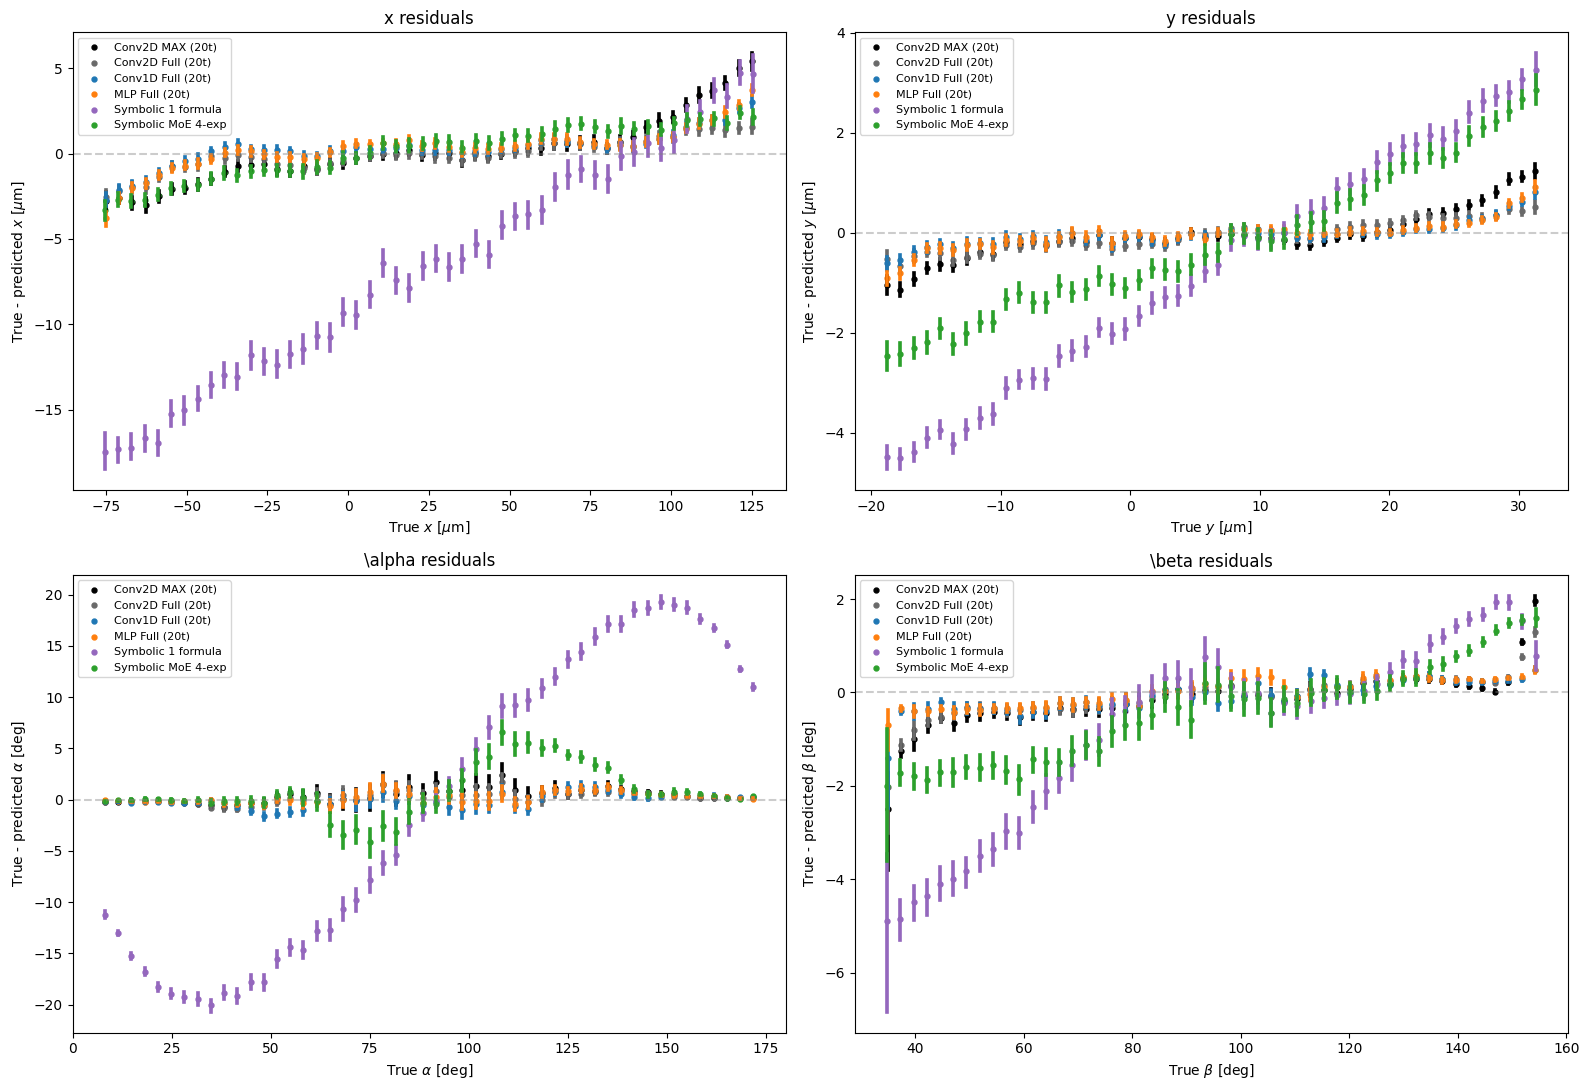

In [5]:
#==============================================================================
# RESIDUALS (2x2: x, y, alpha, beta) -- SLIM files auto-skip alpha
#==============================================================================
fig, axes = plt.subplots(2, 2, figsize=figsize_residuals)
panels = [("x", r"$x$ [$\mu$m]", axes[0, 0]), ("y", r"$y$ [$\mu$m]", axes[0, 1]),
          ("cotA", r"$\alpha$ [deg]", axes[1, 0]), ("cotB", r"$\beta$ [deg]", axes[1, 1])]
for var, name, ax in panels:
    for e in entries:
        if var == "cotA" and not e["has_alpha"]:
            continue
        t, p, sig = get_phys(e, var)
        residual_scatter(ax, t, p, e["color"], e["label"], sigma=sig, band=SHOW_BANDS)
    ax.axhline(0, alpha=0.4, ls="dashed", color="gray")
    ax.set_xlabel("True " + name); ax.set_ylabel("True - predicted " + name)
    ax.set_title(name.split(" ")[0].replace("$", "") + " residuals")
    ax.legend(fontsize=8)
plt.tight_layout()
if output_dir:
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "residuals.png"), dpi=save_dpi, bbox_inches="tight")
plt.show()

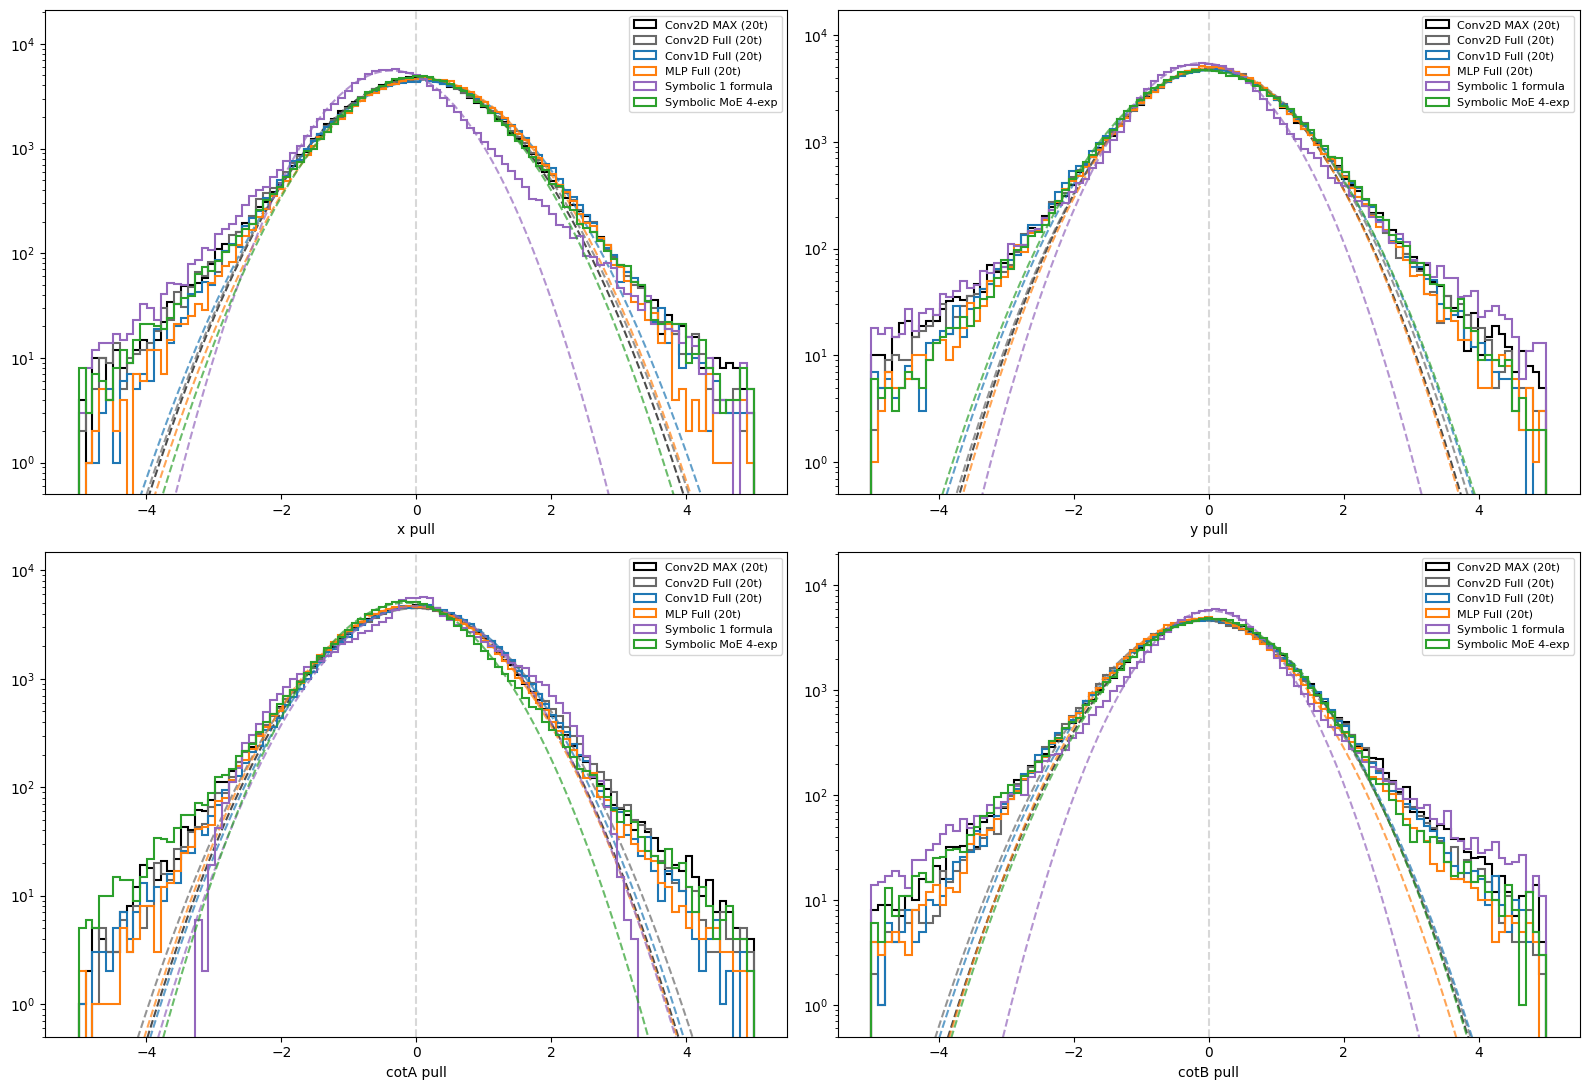

model                    var      pull mu  pull sigma   (sigma~1.0 = calibrated)
Conv2D MAX (20t)         x          0.001       0.926
Conv2D Full (20t)        x          0.022       0.941
Conv1D Full (20t)        x          0.069       0.973
MLP Full (20t)           x          0.097       0.928
Symbolic 1 formula       x         -0.359       0.743
Symbolic MoE 4-exp       x          0.027       0.883
Conv2D MAX (20t)         y          0.019       0.867
Conv2D Full (20t)        y          0.047       0.884
Conv1D Full (20t)        y          0.015       0.912
MLP Full (20t)           y          0.031       0.857
Symbolic 1 formula       y         -0.101       0.754
Symbolic MoE 4-exp       y         -0.003       0.923
Conv2D MAX (20t)         cotA      -0.049       0.920
Conv2D Full (20t)        cotA      -0.015       0.963
Conv1D Full (20t)        cotA       0.010       0.923
MLP Full (20t)           cotA      -0.082       0.922
Symbolic 1 formula       cotA       0.009       0.896
S

In [6]:
#==============================================================================
# PULLS (only files with sigma columns) + Gaussian-fit table
#==============================================================================
sig_entries = [e for e in entries if e["has_sigma"]]
if sig_entries:
    fig, axes = plt.subplots(2, 2, figsize=figsize_pulls)
    pull_results = {}
    for var, name, ax in [("x", "x pull", axes[0, 0]), ("y", "y pull", axes[0, 1]),
                          ("cotA", "cotA pull", axes[1, 0]), ("cotB", "cotB pull", axes[1, 1])]:
        for e in sig_entries:
            if var == "cotA" and not e["has_alpha"]:
                continue
            df = e["df"]
            pull = (df[var + "true"].values - df[var].values) / (df["sigma" + var].values + 1e-12)
            h = ax.hist(pull, bins=np.linspace(-5, 5, 100), histtype="step",
                        label=e["label"], color=e["color"], linewidth=1.5)
            xd = h[1][:-1] + np.diff(h[1]) / 2
            try:
                pars, _ = curve_fit(gauss, xd, h[0], p0=[h[0].max(), 0, 1], maxfev=5000)
                ax.plot(np.linspace(-5, 5, 200), gauss(np.linspace(-5, 5, 200), *pars),
                        color=e["color"], ls="--", alpha=0.7)
                pull_results[(e["label"], var)] = dict(mu=pars[1], sigma=abs(pars[2]))
            except Exception:
                pull_results[(e["label"], var)] = dict(mu=np.nan, sigma=np.nan)
        ax.set_xlabel(name); ax.set_yscale("log")
        ax.axvline(0, alpha=0.3, ls="dashed", color="gray")
        ax.legend(fontsize=8); ax.set_ylim(0.5, None)
    plt.tight_layout()
    if output_dir:
        plt.savefig(os.path.join(output_dir, "pulls.png"), dpi=save_dpi, bbox_inches="tight")
    plt.show()

    print(f"{'model':<24s} {'var':<6s} {'pull mu':>9s} {'pull sigma':>11s}   (sigma~1.0 = calibrated)")
    for (lab, var), r in pull_results.items():
        print(f"{lab:<24s} {var:<6s} {r['mu']:9.3f} {r['sigma']:11.3f}")
else:
    print("no sigma-carrying files loaded -- pulls skipped")

In [7]:
#==============================================================================
# RESOLUTION TABLE: mean / std / I68 per variable (I68 is the paper metric)
#==============================================================================
rows = []
for e in entries:
    for var, unit in [("x", "um"), ("y", "um"), ("cotA", "deg"), ("cotB", "deg")]:
        if var == "cotA" and not e["has_alpha"]:
            continue
        t, p, _ = get_phys(e, var)
        r = t - p
        rows.append(dict(model=e["label"], var=var, unit=unit,
                         mean=np.mean(r), std=np.std(r), I68=i68(r), n=len(r)))
summ = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:8.4f}")
print(summ.to_string(index=False))
if output_dir:
    summ.to_csv(os.path.join(output_dir, "summary.csv"), index=False)

print("\nI68 (half-width of minimal 68% interval):")
print(summ.pivot(index="model", columns="var", values="I68").to_string())

             model  var unit     mean      std      I68      n
  Conv2D MAX (20t)    x   um   0.0712   7.8196   5.2930 108222
  Conv2D MAX (20t)    y   um   0.0091   2.1246   1.2545 108222
  Conv2D MAX (20t) cotA  deg   0.1484   4.7435   1.2024 108222
  Conv2D MAX (20t) cotB  deg  -0.0595   2.6537   1.3796 108222
 Conv2D Full (20t)    x   um  -0.0433   6.6411   4.1449 108222
 Conv2D Full (20t)    y   um  -0.0088   1.9317   1.0045 108222
 Conv2D Full (20t) cotA  deg   0.0425   4.0495   1.0418 108222
 Conv2D Full (20t) cotB  deg   0.0080   2.4445   1.2002 108222
 Conv1D Full (20t)    x   um   0.3076   5.4163   4.2938 108222
 Conv1D Full (20t)    y   um  -0.0054   1.8457   1.0131 108222
 Conv1D Full (20t) cotA  deg  -0.0179   4.2978   0.9342 108222
 Conv1D Full (20t) cotB  deg  -0.0075   2.3380   0.9391 108222
    MLP Full (20t)    x   um   0.3125   5.9307   4.0463 108222
    MLP Full (20t)    y   um   0.0074   1.8058   0.9231 108222
    MLP Full (20t) cotA  deg   0.1048   3.8254   0.8933

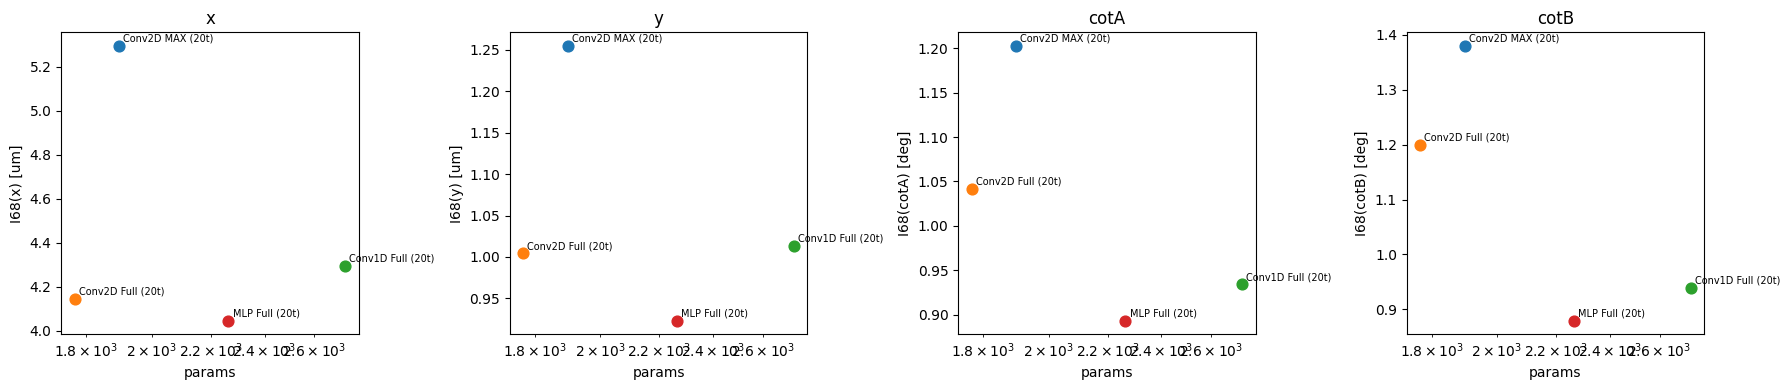

In [8]:
#==============================================================================
# PARAMS vs RESOLUTION scatter (bottom-left = better: fewer params, tighter I68)
#==============================================================================
sub = summ[summ["model"].isin(PARAM_COUNTS)]
if len(sub):
    fig, axs = plt.subplots(1, 4, figsize=(18, 4))
    for ax, var in zip(axs, ["x", "y", "cotA", "cotB"]):
        d = sub[sub["var"] == var]
        for _, row in d.iterrows():
            ax.scatter(PARAM_COUNTS[row["model"]], row["I68"], s=60)
            ax.annotate(row["model"], (PARAM_COUNTS[row["model"]], row["I68"]),
                        fontsize=7, xytext=(3, 3), textcoords="offset points")
        ax.set_xscale("log"); ax.set_xlabel("params")
        ax.set_ylabel(f"I68({var}) [{d['unit'].iloc[0]}]"); ax.set_title(var)
    plt.tight_layout()
    if output_dir:
        plt.savefig(os.path.join(output_dir, "params_vs_resolution.png"), dpi=save_dpi, bbox_inches="tight")
    plt.show()
else:
    print("PARAM_COUNTS has no matching models -- add entries (incl. symbolic) to plot this")